# Sequential Testing and Early Stopping

## Overview

Repeatedly testing accumulating data and stopping when p < 0.05 inflates Type I error severely. With 5 interim looks, the true α can reach 14%; with 20 looks, it exceeds 25%. Sequential testing methods allow early stopping while controlling Type I error through an **α spending function** that allocates significance budget across interim analyses.

**Sequential testing approaches:**

| Method | Approach | Stopping rule |
|---|---|---|
| **O'Brien-Fleming** | Spend very little α early; conservative | Very strong early evidence required |
| **Pocock** | Spend α equally across looks | Same threshold at every look |
| **α-spending (Kim-DeMets)** | Flexible; specify spending function | Customisable |
| **SPRT** | Sequential probability ratio test | Log-likelihood ratio vs. boundaries |
| **mSPRT** | Mixture SPRT — always valid p-values | Stop any time; valid at any n |

**Key principle:** define the maximum n, number of interim looks, and spending function *before* data collection. Changing these mid-experiment reinstates the problem.

---

## Setup

In [5]:
library(tidyverse)
library(ggplot2)
library(gsDesign)      # gsDesign(), gsBoundSummary() — group sequential designs
library(ldbounds)      # ldBounds() — Lan-DeMets spending functions
library(patchwork)

set.seed(42)

# ── Demonstrate: naive peeking inflates Type I error ─────────────────────────
simulate_peeking <- function(n_max=200, n_looks=10, n_sim=5000, alpha=0.05) {
  look_times <- round(seq(n_max/n_looks, n_max, length.out=n_looks))

  map_lgl(1:n_sim, function(sim) {
    # Null hypothesis is TRUE: no real effect
    data <- tibble(
      x = rnorm(n_max),
      y = rnorm(n_max)  # independent of x
    )
    # Stop as soon as p < alpha at any look
    any(map_lgl(look_times, function(n) {
      t.test(data$x[1:n], data$y[1:n])$p.value < alpha
    }))
  }) %>% mean()
}

peek_results <- tibble(
  n_looks = c(1, 2, 5, 10, 20),
  actual_alpha = map_dbl(c(1, 2, 5, 10, 20),
                          ~simulate_peeking(n_looks=.x, n_sim=3000))
)

cat("Type I error from peeking (nominal α=0.05):\n")
print(peek_results %>% mutate(actual_alpha=round(actual_alpha, 4)))

Warning message:
"package 'ldbounds' was built under R version 4.4.3"
Warning message:
"package 'patchwork' was built under R version 4.4.3"


Type I error from peeking (nominal α=0.05):
# A tibble: 5 × 2
  n_looks actual_alpha
    <dbl>        <dbl>
1       1       0.049 
2       2       0.0817
3       5       0.131 
4      10       0.192 
5      20       0.256 


---

## Group Sequential Design with O'Brien-Fleming Boundaries

O'Brien-Fleming group sequential boundaries:
  Analysis               Value Efficacy Futility
 IA 1: 20%                   Z   4.2292  -4.2292
      N: 6         p (1-sided)   0.0000   0.0000
               ~delta at bound   3.7385  -3.7385
           P(Cross) if delta=0   0.0000   0.0000
           P(Cross) if delta=1   0.0010   0.0000
 IA 2: 40%                   Z   2.8881  -2.8881
     N: 11         p (1-sided)   0.0019   0.0019
               ~delta at bound   1.8053  -1.8053
           P(Cross) if delta=0   0.0019   0.0019
           P(Cross) if delta=1   0.0989   0.0000
 IA 3: 60%                   Z   2.2981  -2.2981
     N: 16         p (1-sided)   0.0108   0.0108
               ~delta at bound   1.1729  -1.1729
           P(Cross) if delta=0   0.0114   0.0114
           P(Cross) if delta=1   0.3718   0.0000
 IA 4: 80%                   Z   1.9618  -1.9618
     N: 21         p (1-sided)   0.0249   0.0249
               ~delta at bound   0.8671  -0.8671
           P(Cross) if d

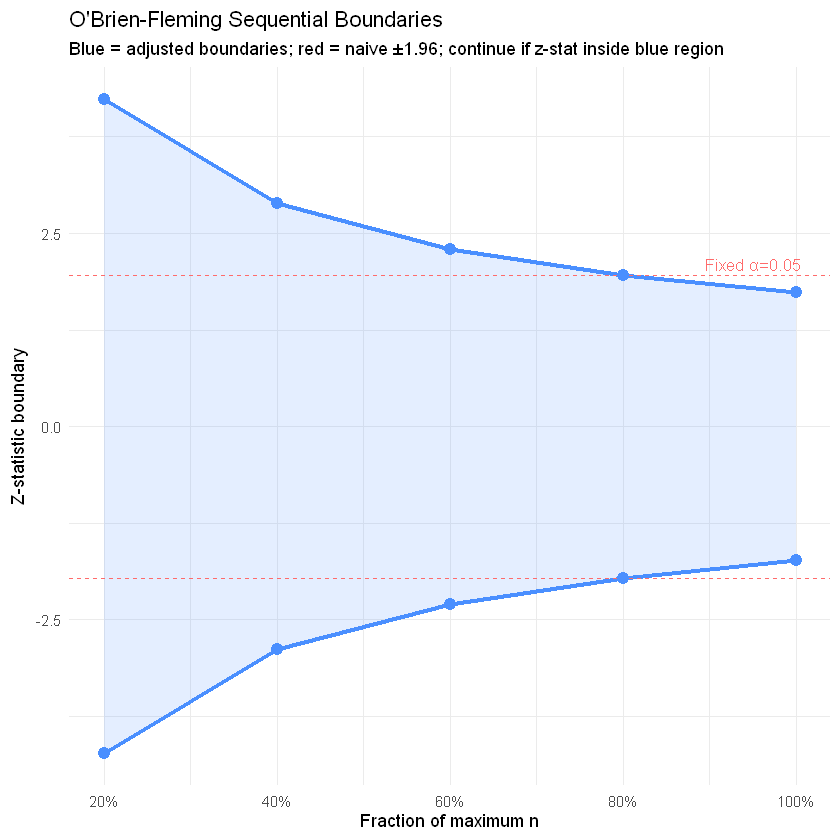

In [6]:
# Group sequential design: 4 interim looks + 1 final
# O'Brien-Fleming: spends very little α early; nearly preserves power

gs_design <- gsDesign::gsDesign(
  k       = 5,          # number of analyses (4 interim + 1 final)
  test.type = 2,        # two-sided
  alpha   = 0.05,
  beta    = 0.20,       # 80% power
  delta   = 0.5,        # standardised effect size (Cohen's d)
  sfu     = gsDesign::sfLDOF  # O'Brien-Fleming spending function
)

cat("O'Brien-Fleming group sequential boundaries:\n")
print(gsDesign::gsBoundSummary(gs_design))

# ── Plot: stopping boundaries ─────────────────────────────────────────────────
bounds_df <- tibble(
  look     = 1:5,
  fraction = gs_design$timing,
  upper_z  = gs_design$upper$bound,
  lower_z  = gs_design$lower$bound,
  upper_p  = 2*pnorm(-abs(gs_design$upper$bound)),
  lower_p  = 2*pnorm(-abs(gs_design$lower$bound))
)

ggplot(bounds_df, aes(x=fraction)) +
  geom_ribbon(aes(ymin=lower_z, ymax=upper_z),
              fill="#4a8fff", alpha=0.15) +
  geom_line(aes(y=upper_z), color="#4a8fff", linewidth=1.2) +
  geom_line(aes(y=lower_z), color="#4a8fff", linewidth=1.2) +
  geom_hline(yintercept=c(-1.96,1.96), linetype="dashed", color="#ff6b6b") +
  geom_point(aes(y=upper_z), size=3, color="#4a8fff") +
  geom_point(aes(y=lower_z), size=3, color="#4a8fff") +
  annotate("text", x=0.95, y=2.1, label="Fixed α=0.05", color="#ff6b6b", size=3.5) +
  scale_x_continuous(labels=scales::percent) +
  labs(title="O'Brien-Fleming Sequential Boundaries",
       subtitle="Blue = adjusted boundaries; red = naive ±1.96; continue if z-stat inside blue region",
       x="Fraction of maximum n", y="Z-statistic boundary") +
  theme_minimal()

---

## Simulating a Sequential Trial

In [7]:
# Simulate data accumulating over time with true effect d=0.5
n_max  <- ceiling(gs_design$n.I[5])
true_d <- 0.5

sim_data <- tibble(
  obs      = 1:n_max,
  control  = rnorm(n_max, 0, 1),
  treatment= rnorm(n_max, true_d, 1)
)

# Compute z-statistic at each interim look
look_ns <- ceiling(gs_design$n.I)

interim_results <- map_dfr(seq_along(look_ns), function(i) {
  n  <- look_ns[i]
  tst <- t.test(sim_data$treatment[1:n], sim_data$control[1:n])
  tibble(
    look      = i,
    n         = n,
    z_stat    = qnorm(1 - tst$p.value/2) * sign(diff(tst$estimate)),
    p_value   = tst$p.value,
    upper_bnd = gs_design$upper$bound[i],
    lower_bnd = gs_design$lower$bound[i],
    stop_early= abs(z_stat) >= gs_design$upper$bound[i]
  )
})

print(interim_results %>% mutate(across(where(is.numeric), ~round(.x, 3))))

first_stop <- which(interim_results$stop_early)[1]
if (!is.na(first_stop)) {
  cat(sprintf("\n→ Would stop at look %d (n=%d, %.0f%% of max n)\n",
              first_stop, look_ns[first_stop],
              look_ns[first_stop]/n_max*100))
} else {
  cat("\n→ Would continue to final look (n_max)\n")
}

# A tibble: 5 × 7
   look     n z_stat p_value upper_bnd lower_bnd stop_early
  <dbl> <dbl>  <dbl>   <dbl>     <dbl>     <dbl> <lgl>     
1     1     6 -0.004   0.997      4.23     -4.23 FALSE     
2     2    11 -1.46    0.144      2.89     -2.89 FALSE     
3     3    16 -1.12    0.262      2.30     -2.30 FALSE     
4     4    21 -2.22    0.026      1.96     -1.96 TRUE      
5     5    26 -2.60    0.009      1.74     -1.74 TRUE      

→ Would stop at look 4 (n=21, 81% of max n)


---

## Common Pitfalls

**1. Peeking at p-values and stopping when significant**  
This is the most common error in sequential data analysis. Even a single unplanned interim look inflates Type I error. If interim analysis is anticipated, it must be pre-specified — the number of looks, the timing, and the stopping boundaries must all be defined before data collection begins.

**2. Specifying the sequential design after observing a trend in the data**  
Fitting a sequential boundary to data that have already been collected — even to "formalise" an early stop that seemed justified — is post hoc. The boundary must be pre-specified. If an unplanned stop has already occurred, report it transparently as exploratory and seek independent replication.

**3. Using Pocock boundaries when early stopping for efficacy is unlikely**  
Pocock boundaries spend α equally at each look, requiring the same (very conservative) threshold at the final analysis as at interim looks. This reduces overall power substantially. O'Brien-Fleming spends very little α early — requiring overwhelming evidence to stop early — and preserves nearly all power at the final look. Prefer O'Brien-Fleming unless there is a strong reason to stop early.

**4. Not adjusting confidence intervals after early stopping**  
When a trial stops early due to efficacy, the observed effect size is inflated (winner's curse). Naive confidence intervals computed at the stopping point are too narrow and centred on a biased estimate. Median-unbiased estimates and stage-adjusted CIs must be used — `gsDesign` provides these.

**5. Treating the maximum n as the expected n**  
Sequential designs are sized to achieve 80% power at the maximum n. The expected n if the true effect is large may be much smaller — the advantage of sequential testing is stopping early when evidence is overwhelming. Report both the maximum n and the expected n under the assumed effect size when justifying the design.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*